# Flight Delay Prediction Model Training

In this notebook we build machine learning models to predict whether a flight will be delayed.

Steps included:

- Feature selection
- Data preprocessing
- Train/test split
- Model training
- Model evaluation
- Model serialization

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import pickle

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [ ]:
df = pd.read_csv("C:\\Users\\ASUS\\Desktop\\Data_Science_Internship\\Final_Project\\Dataset\\cleaned_flights.csv")

df.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Delayed,DepHour,ArrHour
0,2008,3,25,2,1124.0,1221.0,WN,1095,N909WN,57.0,...,N,0,0.0,0.0,0.0,0.0,0.0,0,11,12
1,2008,8,9,6,1152.0,1555.0,AA,1690,N5ELAA,183.0,...,N,0,22.0,0.0,13.0,0.0,0.0,1,11,15
2,2008,12,13,6,1226.0,1405.0,EV,5615,N752EV,99.0,...,N,0,0.0,0.0,0.0,0.0,0.0,0,12,13
3,2008,1,21,1,2046.0,2158.0,WN,1274,N642WN,132.0,...,N,0,7.0,0.0,17.0,0.0,49.0,1,19,20
4,2008,12,26,5,1759.0,2026.0,OO,6180,N742SK,87.0,...,N,0,0.0,0.0,0.0,0.0,49.0,1,17,19


## Feature Selection


In [ ]:
features = [
    "Month",
    "DayOfWeek",
    "DepHour",
    "ArrHour",
    "UniqueCarrier",
    "Origin",
    "Dest",
    "Distance",
    "WeatherDelay",
    "NASDelay",
    "LateAircraftDelay"
]

df = df[features + ["Delayed"]]

## Encode Categorical Columns

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["UniqueCarrier"] = le.fit_transform(df["UniqueCarrier"])
df["Origin"] = le.fit_transform(df["Origin"])
df["Dest"] = le.fit_transform(df["Dest"])

In [ ]:
from sklearn.utils import resample

majority = df[df.Delayed==1]
minority = df[df.Delayed==0]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

df_balanced = pd.concat([majority, minority_upsampled])

## Prepare Data

In [ ]:
X = df_balanced.drop("Delayed", axis=1)
y = df_balanced["Delayed"]

## Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Machine Learning Models

In this section we train multiple machine learning models to predict whether a flight will be delayed.

Models used:

1. Logistic Regression
2. Decision Tree
3. Random Forest

We compare their performance to select the best model.

### Logistic Regression

Logistic Regression is a baseline classification model that estimates the probability of a flight delay.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.87135


### Decision Tree

Decision Trees learn decision rules from data by splitting features into branches.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8378


### Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8835


## Model Comparison

We compare the accuracy of all trained models to determine the best performing algorithm.

In [ ]:
results = {
    "Logistic Regression": lr_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy
}

results

{'Logistic Regression': 0.87135,
 'Decision Tree': 0.8378,
 'Random Forest': 0.8835}

## Confusion Matrix

The confusion matrix helps evaluate how well the model predicts delayed and non-delayed flights.

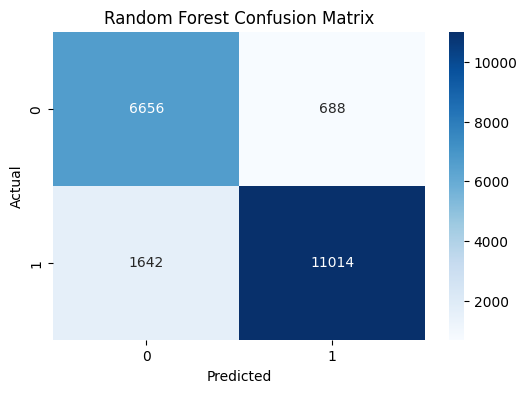

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

## Feature Importance

Feature importance shows which factors contribute most to flight delays.

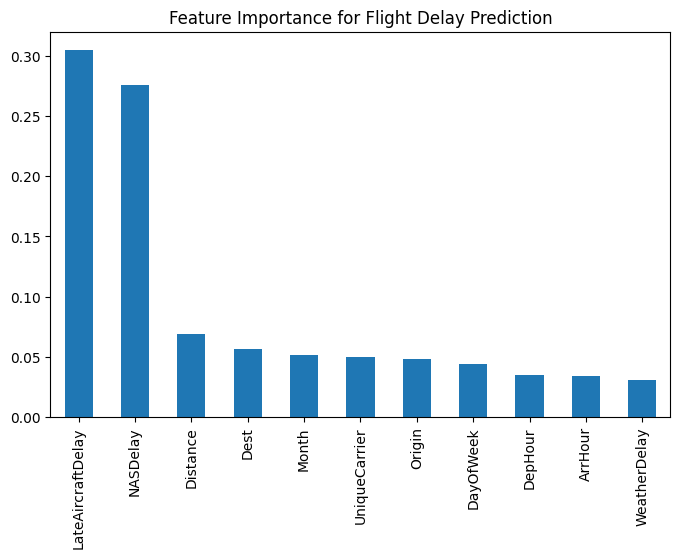

In [ ]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)


plt.figure(figsize=(8,5))

feature_importance.plot(kind="bar")

plt.title("Feature Importance for Flight Delay Prediction")

plt.show()

## Model Serialization

After training the machine learning model, we save the trained model using **Pickle**.  
This allows the model to be reused later in the deployment phase without retraining.

The saved model will be used in the **Streamlit web application** for real-time flight delay prediction.

In [ ]:
import pickle

# Save the trained Random Forest model
with open("flight_delay_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Model saved successfully!")

Model saved successfully!


## Saving Label Encoders

The categorical variables were encoded using LabelEncoder.  
We save these encoders so the Streamlit application can transform new input data correctly.

In [ ]:
with open("carrier_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

## Testing Model Prediction

We test the saved model with a sample input to verify that it can make predictions correctly.

In [ ]:
sample = X_test.iloc[0].values.reshape(1, -1)

prediction = rf.predict(sample)

print("Prediction:", prediction)

Prediction: [1]
